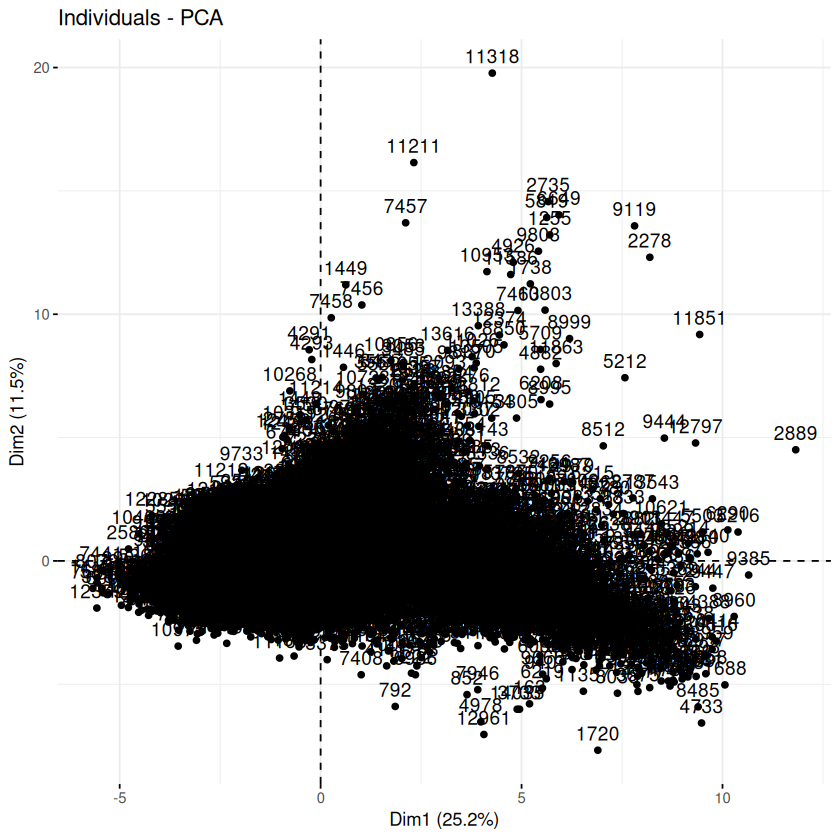

In [ ]:
source("../R/shared_data.R")
data_features_core <- load_analysis_data()

library(dotenv)
load_dot_env(file = "../../.env")

# Tu récupères l'objet complet avec tous ses calculs
res_pca <- readRDS("acp.rds")

# Tu peux maintenant refaire tes graphiques immédiatement
library(factoextra)
fviz_pca_ind(res_pca)

api_key <- Sys.getenv("MY_MAPS_API_KEY")

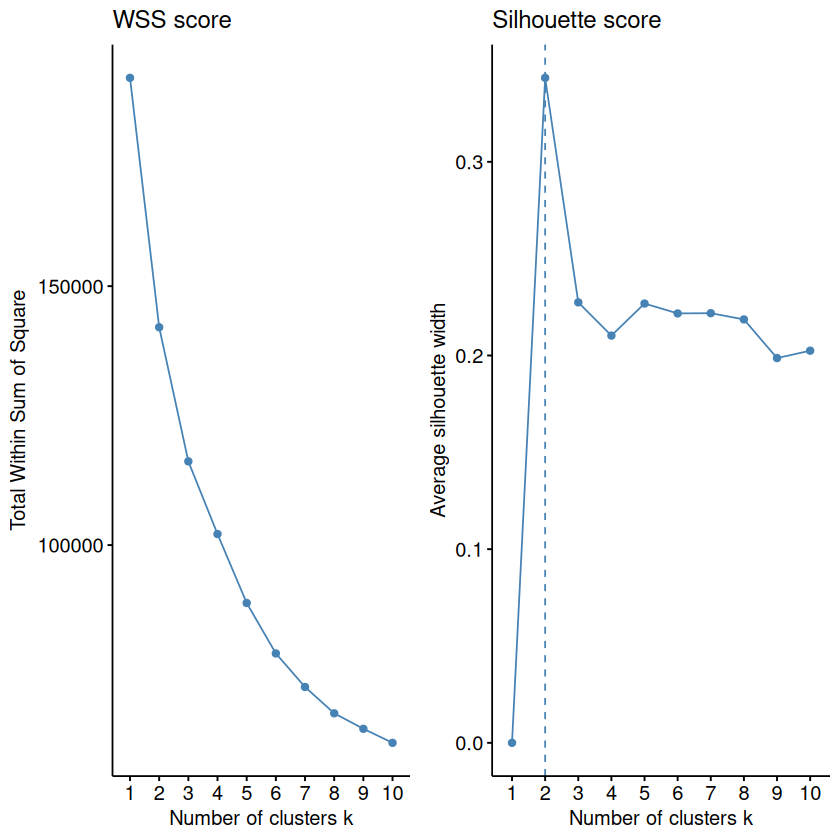

In [ ]:
##K-Means
library(gridExtra)

acp=res_pca$ind$coord

p1 = fviz_nbclust(acp, FUNcluster=stats::kmeans,iter.max = 50, method="wss") +
    ggtitle("WSS score")

p2 = fviz_nbclust(acp,FUNcluster=stats::kmeans,iter.max = 50, method="silhouette") +
    ggtitle("Silhouette score")

grid.arrange(p1,p2,ncol=2)

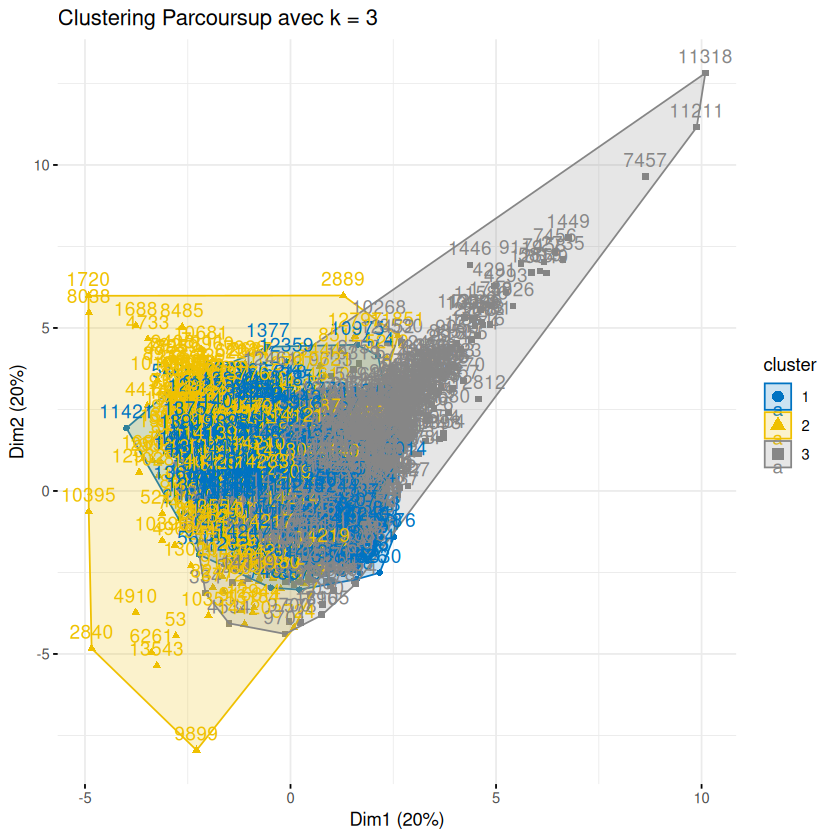

In [ ]:
# Fixer la graine pour la reproductibilité (comme dans les bonnes pratiques)
set.seed(123)

# Lancement du K-means
k_choisi <- 3
km_res_pca <- kmeans(acp, centers = k_choisi, nstart = 25)

# Visualisation des clusters sur le plan factoriel (PCA)
fviz_cluster(km_res, data = acp,
             ellipse.type = "convex",
             palette = "jco",
             ggtheme = theme_minimal()) +
  ggtitle(paste("Clustering Parcoursup avec k =", k_choisi))

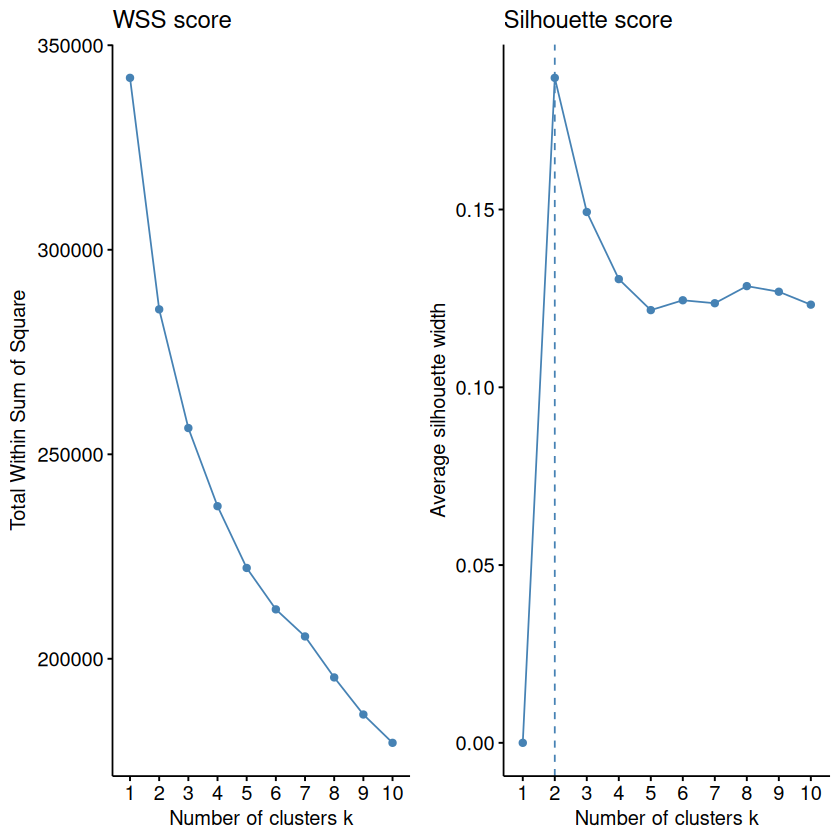

In [ ]:
library(gridExtra)
# 1. Mise à l'échelle
data_num <- data_features_core[, sapply(data_features_core, is.numeric)]

# 2. NETTOYAGE : Supprimer les lignes avec des valeurs manquantes (NA)
# Le K-means et le scale ne supportent pas les trous dans les données
data_clean <- na.omit(data_num)

# 3. Mise à l'échelle (scale) sur les données propres
data_scaled <- scale(data_clean)

p1 = fviz_nbclust(data_scaled, FUNcluster=stats::kmeans,iter.max = 50, method="wss") +
    ggtitle("WSS score")

p2 = fviz_nbclust(data_scaled,FUNcluster=stats::kmeans,iter.max = 50, method="silhouette") +
    ggtitle("Silhouette score")

grid.arrange(p1,p2,ncol=2)

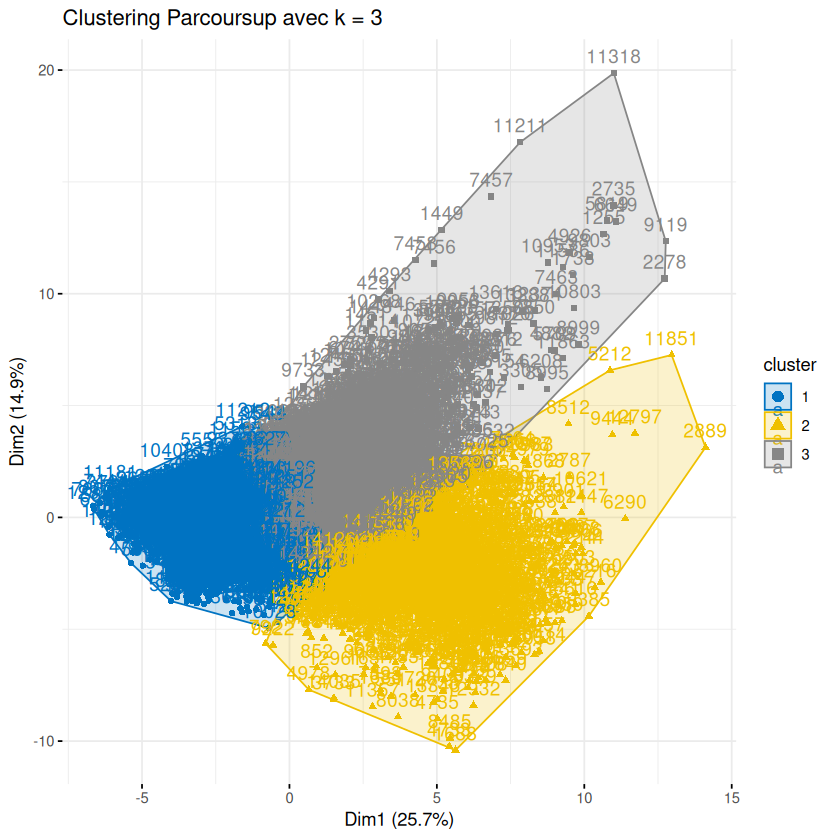

In [ ]:
# Fixer la graine pour la reproductibilité (comme dans les bonnes pratiques)
set.seed(123)

# Lancement du K-means
k_choisi <- 3
km_res <- kmeans(data_scaled, centers = k_choisi, nstart = 25)

# Visualisation des clusters sur le plan factoriel (PCA)
fviz_cluster(km_res, data = data_scaled,
             ellipse.type = "convex",
             palette = "jco",
             ggtheme = theme_minimal()) +
  ggtitle(paste("Clustering Parcoursup avec k =", k_choisi))

   
       1    2    3
  1 5728    6 1742
  2    0 1471   90
  3  255   60 4900


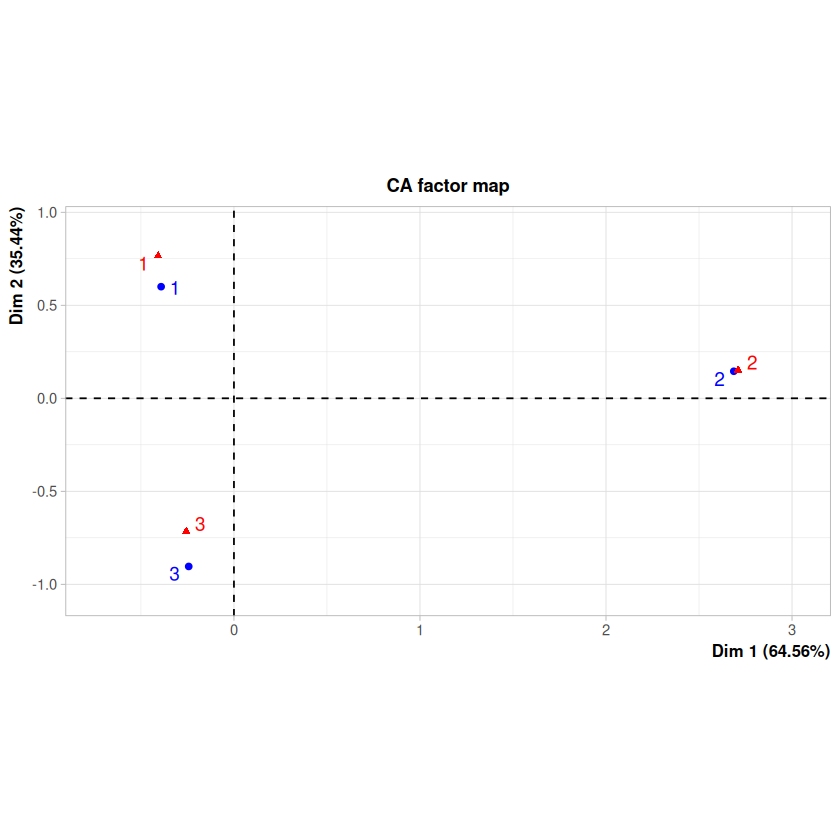

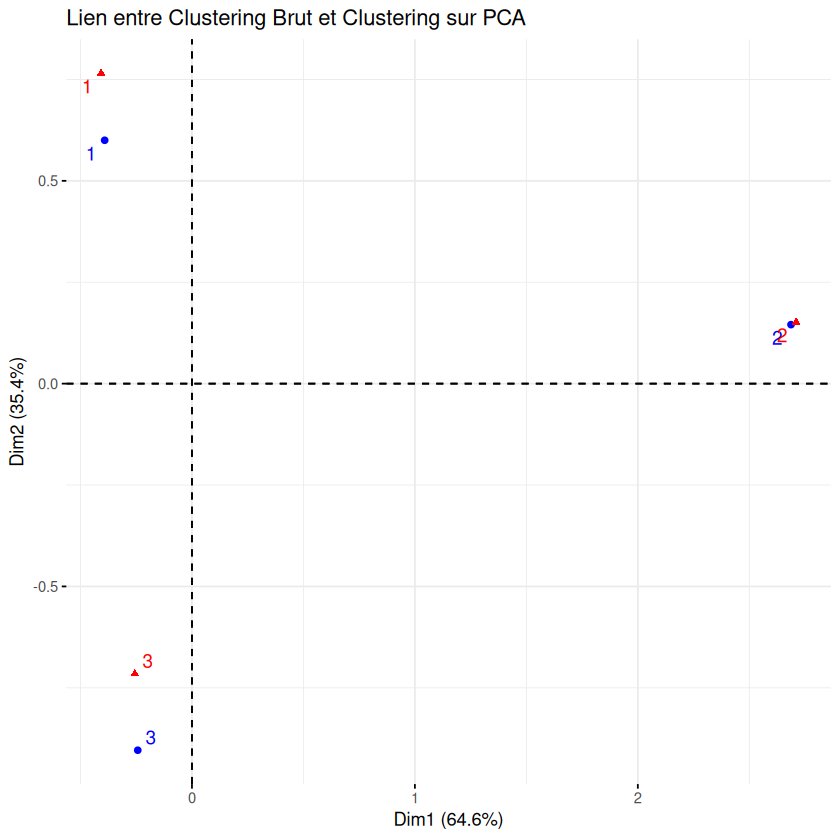

In [ ]:
library(FactoMineR)
tbl = table(km_res$cluster, km_res_pca$cluster)
print(tbl)
ca = CA(tbl, graph=TRUE)
fviz_ca_biplot(ca,
               repel = TRUE,        # Évite le chevauchement des étiquettes
               col.row = "blue",    # Couleur pour km_res (Lignes)
               col.col = "red",     # Couleur pour km_res_pca (Colonnes)
               ggtheme = theme_minimal()) +
  ggtitle("Lien entre Clustering Brut et Clustering sur PCA")

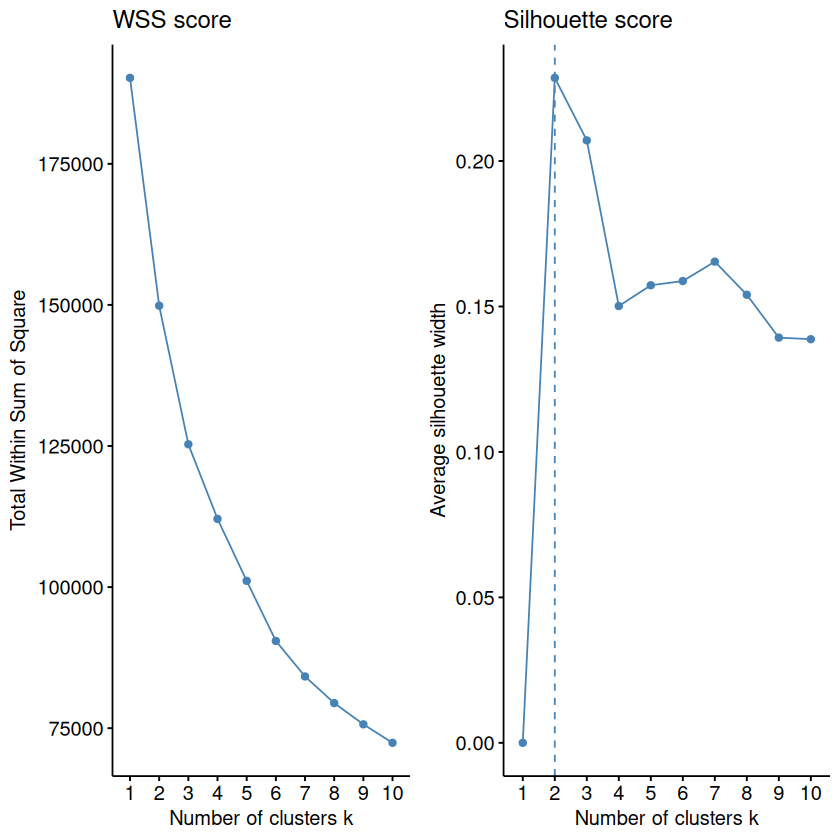

In [ ]:
##CAH
p1 = fviz_nbclust(acp, FUNcluster=hcut, method="wss") + ggtitle("WSS score")
p2 = fviz_nbclust(acp, FUNcluster=hcut, method="silhouette") + ggtitle("Silhouette score")
grid.arrange(p1,p2,ncol=2)


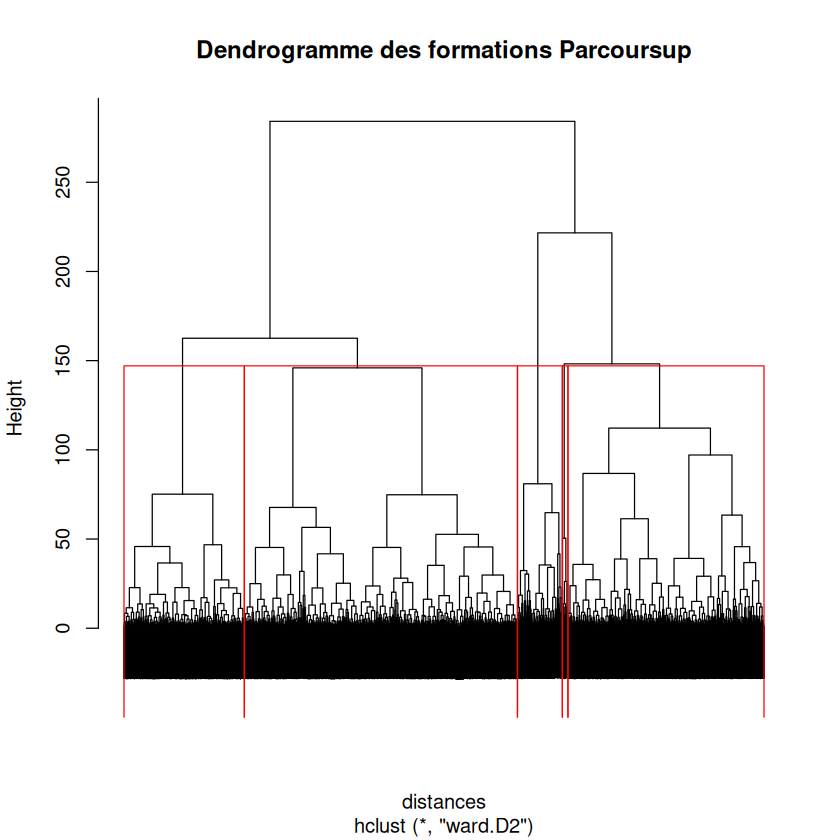

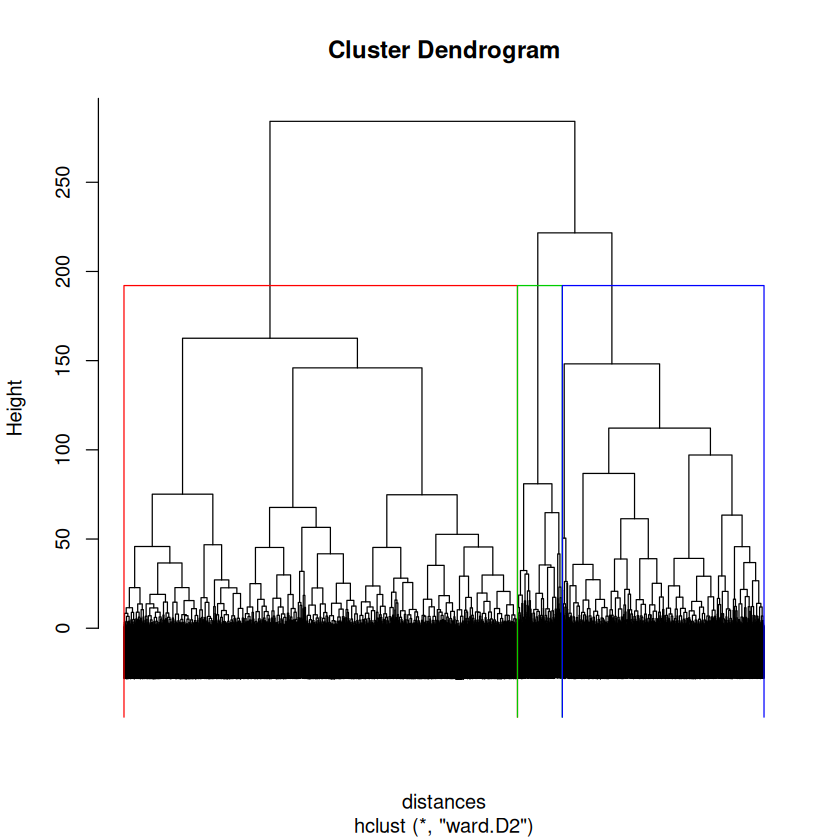

In [ ]:
# 1. Calcul de la matrice de distances (Euclidienne par défaut)
distances <- dist(acp, method = "euclidean")

# 2. Lancement de la CAH avec la méthode de Ward
res_cah <- hclust(distances, method = "ward.D2")

# 3. Affichage du dendrogramme (l'arbre)
plot(res_cah, labels = FALSE, main = "Dendrogramme des formations Parcoursup")
# On ajoute une ligne de coupe pour visualiser vos k clusters (ex: k=2)
rect.hclust(res_cah, k = 3, border = "red")

# 1. On coupe l'arbre pour obtenir 3 groupes (par exemple)
groupes_cah <- cutree(res_cah, k = 3)

# 2. On affiche le dendrogramme avec des encadrés pour y voir clair
plot(res_cah, labels = FALSE)
rect.hclust(res_cah, k = 3, border = 2:4) # Dessine des cadres de couleurs
###on a fait avec 3 clusters mais 2 semble la meilleur possibilité comme k-means